# A Geometric Theory of Decision Boundaries in Structured Markov Decision Processes

### Execution Guidelines

The following Python scripts must be executed in order:
* `run_section8_policy_geometry_vF.py`
* `run_section8_learning_validation_robust.py`
* `run_section8_learning_validation_robust_final3.py`

### Output Directories

All generated results, data, and figures will be stored across the following directories:
* `/Results_section8_vF`
* `/Results_section8_vF2`
* `/Results_section8_learning_robust_final3`

In [1]:
# Packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import seaborn as sns


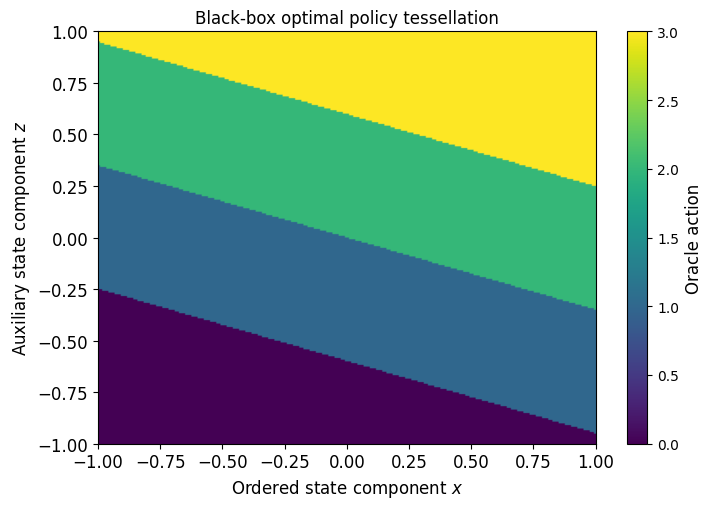

In [2]:
# Figue 1

df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF/data/fig01_blackbox_tessellation_data_vF.csv")

x_vals = np.sort(df["x"].unique())
z_vals = np.sort(df["z"].unique())

m_x = len(x_vals)
m_z = len(z_vals)

policy_grid = df["policy"].to_numpy().reshape(m_z, m_x)

fig, ax = plt.subplots(figsize=(7.4, 5.2))

im = ax.imshow(
    policy_grid.T,
    origin="lower",
    extent=[x_vals.min(), x_vals.max(), z_vals.min(), z_vals.max()],
    aspect="auto"
)

ax.set_xlabel("Ordered state component $x$", fontsize=12)
ax.set_ylabel("Auxiliary state component $z$",fontsize=12)
ax.set_title("Black-box optimal policy tessellation")

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Oracle action",fontsize=12)

fig.tight_layout()

plt.show()


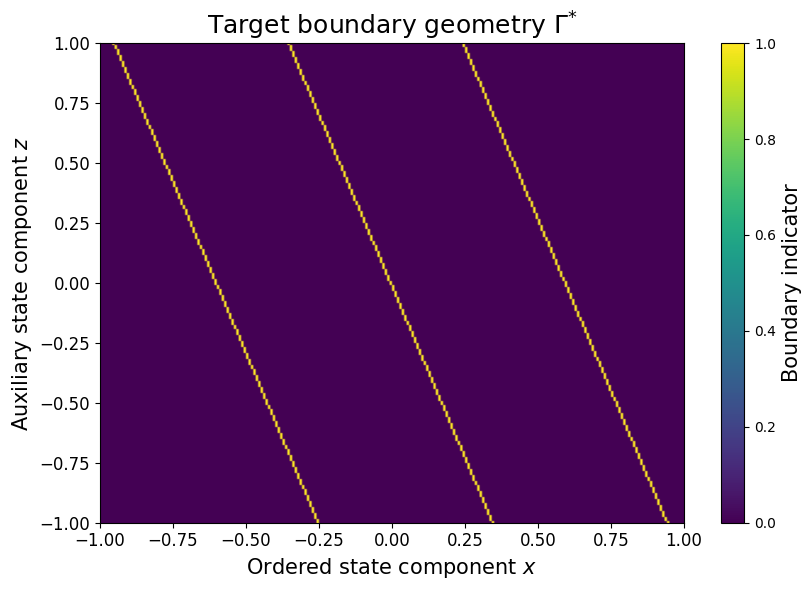

In [3]:
# Figure 2
df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF/data/fig02_blackbox_boundary_data_vF.csv")

x_vals = np.sort(df["x"].unique())
z_vals = np.sort(df["z"].unique())

nx = len(x_vals)
nz = len(z_vals)

boundary_grid = (df["boundary"].to_numpy().reshape(nz, nx))

fig, ax = plt.subplots(figsize=(8.5, 6))

im = ax.imshow(
    boundary_grid,
    origin="lower",
    extent=[
        x_vals.min(),
        x_vals.max(),
        z_vals.min(),
        z_vals.max()
    ],
    aspect="auto"
)

ax.set_title(r"Target boundary geometry $\Gamma^{*}$", fontsize=18)
ax.set_xlabel(r"Ordered state component $x$",fontsize=15)
ax.set_ylabel(r"Auxiliary state component $z$",fontsize=15)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    "Boundary indicator",
    fontsize=15
)

plt.tight_layout()


plt.show()


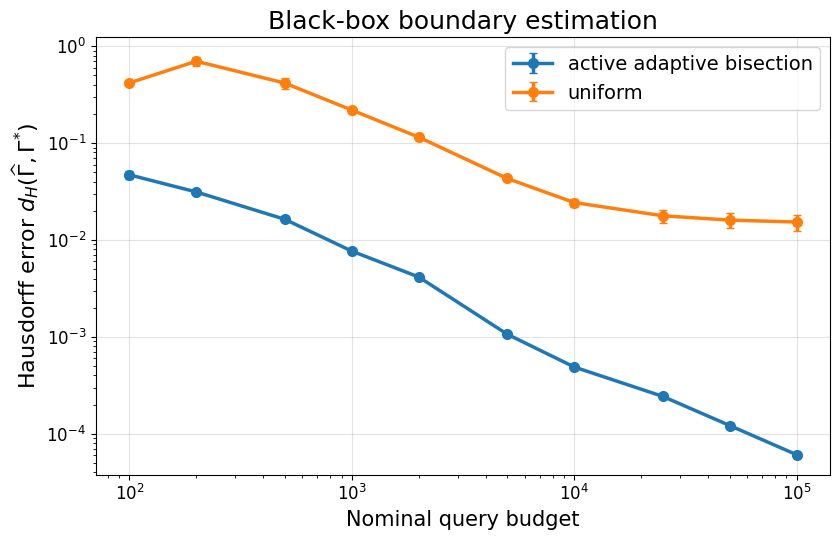

In [4]:
# Figure 3 
df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF/data/fig03_04_blackbox_learning_summary_vF.csv")


label_map = {"active_adaptive_bisection": "active adaptive bisection",
             "uniform": "uniform"}

df["label"] = df["strategy"].map(label_map)


fig, ax = plt.subplots(figsize=(8.5, 5.5))

for strategy, sub in df.groupby("strategy"):
    sub = sub.sort_values("samples")

    ax.errorbar(
        sub["samples"],
        sub["d_H_mean"],
        yerr=sub["d_H_ci95"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        capsize=3,
        label=label_map.get(strategy, strategy)
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Black-box boundary estimation", fontsize=18)
ax.set_xlabel("Nominal query budget", fontsize=15)
ax.set_ylabel(r"Hausdorff error $d_H(\widehat{\Gamma},\Gamma^{*})$", fontsize=16)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(fontsize=14)
ax.grid(True, alpha=0.35)

plt.tight_layout()

plt.show()


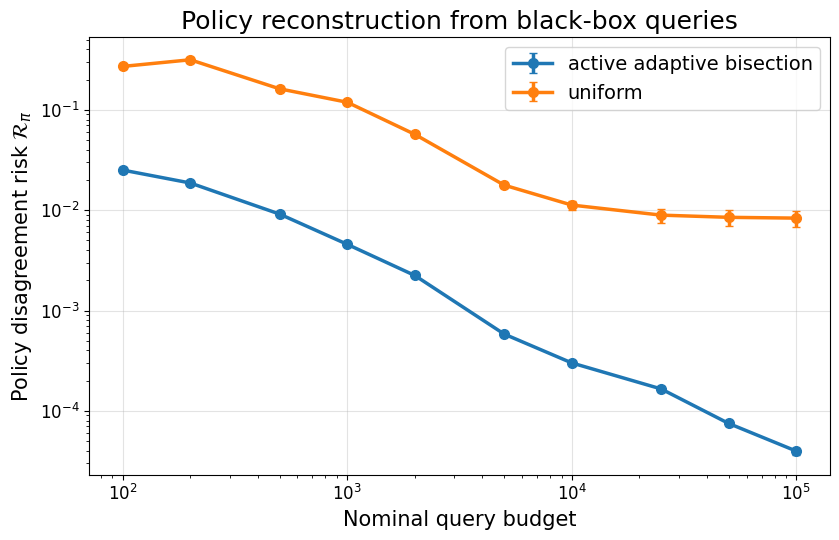

In [5]:
# Figure 4
fig, ax = plt.subplots(figsize=(8.5, 5.5))

for strategy, sub in df.groupby("strategy"):
    sub = sub.sort_values("samples")

    ax.errorbar(
        sub["samples"],
        sub["policy_risk_mean"],
        yerr=sub["policy_risk_ci95"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        capsize=3,
        label=label_map.get(strategy, strategy)
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Policy reconstruction from black-box queries", fontsize=18)
ax.set_xlabel("Nominal query budget", fontsize=15)
ax.set_ylabel(r"Policy disagreement risk $\mathcal{R}_{\pi}$", fontsize=15)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(fontsize=14)
ax.grid(True, alpha=0.35)

plt.tight_layout()

plt.show()


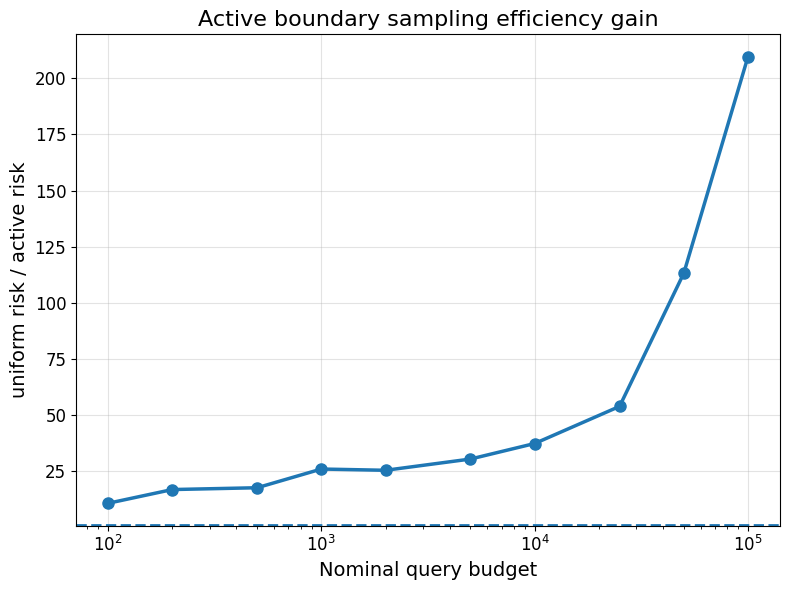

In [6]:
# figure 5

df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF/data/fig05_active_efficiency_gain_data_vF.csv")

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(
    df["samples"],
    df["risk_reduction_factor"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.axhline(1.0, linestyle="--", linewidth=2)

ax.set_xscale("log")

ax.set_title("Active boundary sampling efficiency gain", fontsize=16)

ax.set_xlabel("Nominal query budget", fontsize=14)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_ylabel(
    "uniform risk / active risk",
    fontsize=14
)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


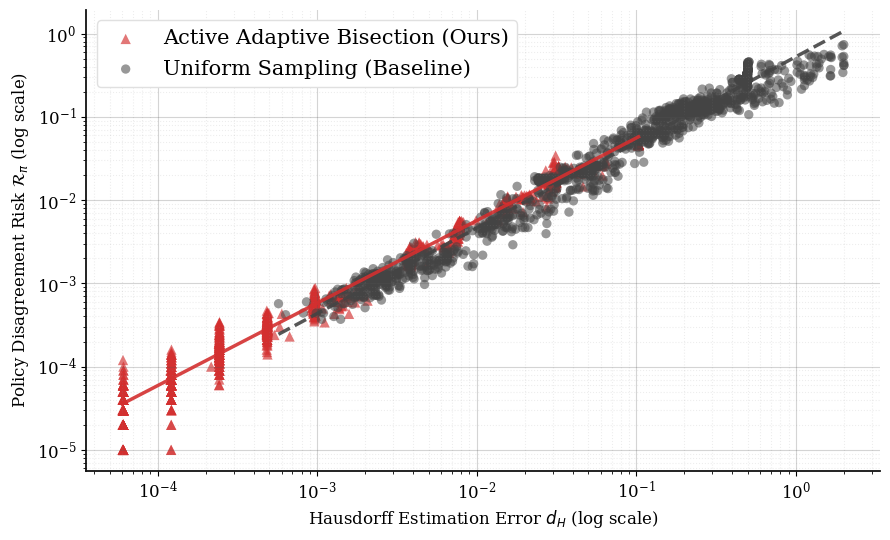

In [7]:
# Figure 6

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.3

df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF/data/fig06_policy_risk_vs_dh_blackbox_data_vF.csv")
df = df[(df["d_H"] > 0) & (df["policy_risk"] > 0)]

fig, ax = plt.subplots(figsize=(9, 5.5))

strat_config = {
    "uniform": {
        "label": "Uniform Sampling (Baseline)",
        "color": "#444444",
        "marker": "o",
        "alpha": 0.55,
        "s": 45,
    },
    "active_adaptive_bisection": {
        "label": "Active Adaptive Bisection (Ours)",
        "color": "#D32F2F",
        "marker": "^",
        "alpha": 0.65,
        "s": 55,
    },
}

for strategy, sub in df.groupby("strategy"):
    config = strat_config[strategy]

    ax.scatter(
        sub["d_H"],
        sub["policy_risk"],
        alpha=config["alpha"],
        s=config["s"],
        c=config["color"],
        marker=config["marker"],
        edgecolors="none",
        label=config["label"],
    )

    log_x = np.log10(sub["d_H"])
    log_y = np.log10(sub["policy_risk"])
    m, b = np.polyfit(log_x, log_y, 1)

    x_space = np.linspace(sub["d_H"].min(), sub["d_H"].max(), 100)
    y_space = 10 ** (m * np.log10(x_space) + b)

    ax.plot(
        x_space,
        y_space,
        color=config["color"],
        linestyle="--" if strategy == "uniform" else "-",
        linewidth=2.5,
        alpha=0.9,
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Hausdorff Estimation Error $d_H$ (log scale)", fontsize=12)
ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$ (log scale)", fontsize=12)

ax.grid(True, which="major", linestyle="-", alpha=0.25, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.15, color="#888888")

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=15,
    loc="upper left",
)

sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()


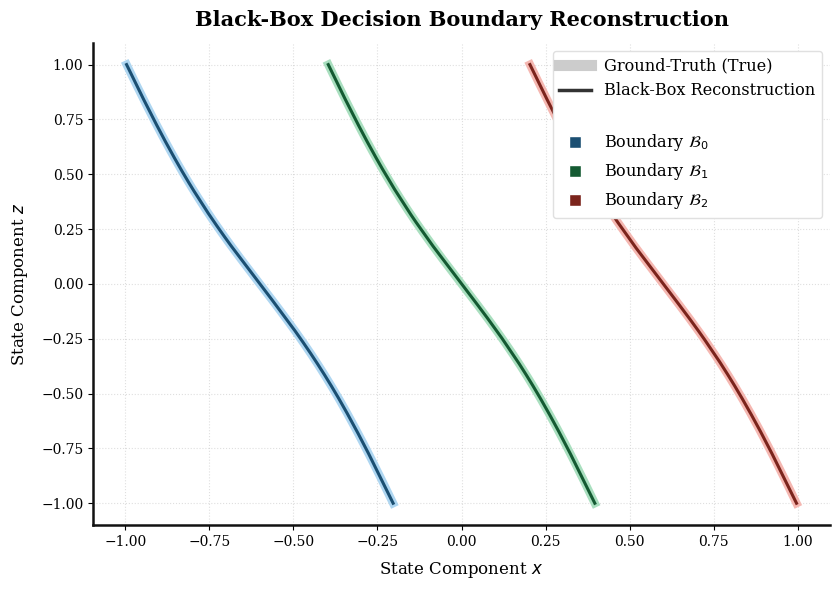

In [8]:
# Figure 7

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.8

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF/data/fig08_reconstructed_boundaries_data_vF.csv"
df = pd.read_csv(csv_path)

fig, ax = plt.subplots(figsize=(8.5, 6.))

colors_config = {
    0: {"true": "#AED6F1", "estimated": "#1B4F72", "name": r"$\mathcal{B}_0$"},
    1: {"true": "#A9DFBF", "estimated": "#145A32", "name": r"$\mathcal{B}_1$"},
    2: {"true": "#F5B7B1", "estimated": "#7B241C", "name": r"$\mathcal{B}_2$"},
}

for b in sorted(df["boundary"].unique()):
    sub = df[df["boundary"] == b].sort_values("z")
    cfg = colors_config[b]

    ax.plot(sub["true_x"], sub["z"], color=cfg["true"], linewidth=6.0, linestyle="-")

    ax.plot(
        sub["estimated_x"],
        sub["z"],
        color=cfg["estimated"],
        linewidth=2.2,
        linestyle="-",
    )

    ax.fill_betweenx(
        sub["z"], sub["true_x"], sub["estimated_x"], color=cfg["estimated"], alpha=0.10
    )

legend_elements = [
    Line2D(
        [0],
        [0],
        color="#cccccc",
        linewidth=8.0,
        linestyle="-",
        label="Ground-Truth (True)",
    ),
    Line2D(
        [0],
        [0],
        color="#333333",
        linewidth=2.5,
        linestyle="-",
        label="Black-Box Reconstruction",
    ),
    Line2D([0], [0], linewidth=0, label=""),
]

for b, cfg in colors_config.items():
    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor=cfg["estimated"],
            markersize=9,
            label=f"Boundary {cfg['name']}",
        )
    )

ax.legend(
    handles=legend_elements,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=11.6,
    loc="best",
)

ax.set_xlabel(r"State Component $x$", fontsize=12, labelpad=8)
ax.set_ylabel(r"State Component $z$", fontsize=12, labelpad=8)
ax.set_title(
    "Black-Box Decision Boundary Reconstruction", fontsize=15, weight="bold", pad=12
)

ax.grid(True, linestyle=":", alpha=0.4, color="#b0b0b0")
sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=10)

plt.tight_layout()
plt.show()


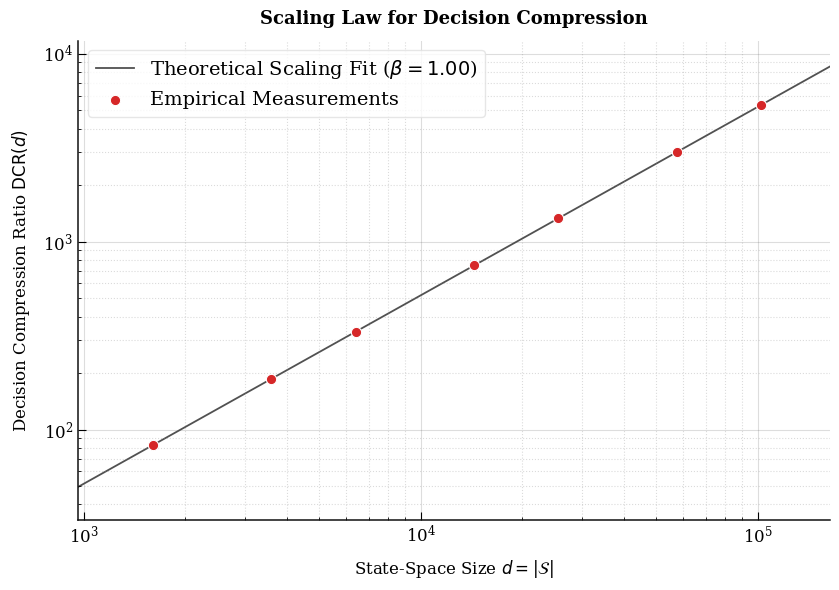

In [9]:
# =====================================================================
# Additional figures
# =====================================================================


# Figure 8

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.1
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF2/data/fig08_dcr_scaling_data_vF2.csv")

n = df["states"].values
dcr = df["DCR_mean"].values
err = df["DCR_sd"].values
beta, intercept = np.polyfit(np.log(n), np.log(dcr), 1)

fig, ax = plt.subplots(figsize=(8.5, 6))

n_grid = np.geomspace(n.min() * 0.5, n.max() * 2.0, 300)
fit_curve = np.exp(intercept) * n_grid**beta

ax.plot(
    n_grid, fit_curve,
    color="#333333",
    linestyle="-",
    linewidth=1.3,
    alpha=0.85,
    zorder=1,
    label=fr"Theoretical Scaling Fit ($\beta = {beta:.2f}$)"
)

ax.errorbar(
    n, dcr,
    yerr=err,
    fmt="none",
    ecolor="#D62728",
    linewidth=1.2,
    capsize=0,
    alpha=0.7,
    zorder=2
)

ax.scatter(
    n, dcr,
    s=55,
    color="#D62728",
    edgecolor="#ffffff",
    linewidths=0.8,
    zorder=3,
    label="Empirical Measurements"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

ax.set_xlim(n.min() * 0.6, n.max() * 1.6)
ax.set_ylim(dcr.min() * 0.4, dcr.max() * 2.2)

ax.set_xlabel(r"State-Space Size $d = |\mathcal{S}|$", fontsize=12, labelpad=8)
ax.set_ylabel(r"Decision Compression Ratio $\mathrm{DCR}(d)$", fontsize=12, labelpad=8)
ax.set_title("Scaling Law for Decision Compression", fontsize=13, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.20, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.30, color="#888888")

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    fontsize=14.,
    loc="best"
)

sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()



alpha = 0.6931


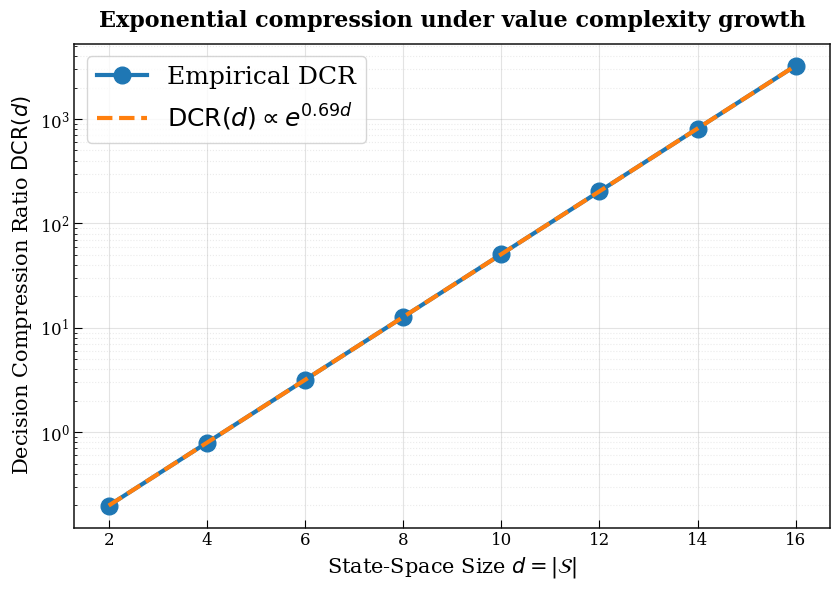

In [10]:
# Figure 9

df = pd.read_csv("C:/Users/fredy/Downloads/Results_section8_vF2/data/fig09_exponential_compression_data_vF2.csv")

d = df["dimension"].values
dcr = df["DCR_mean"].values

alpha, beta = np.polyfit(d, np.log(dcr),1)

print(f"alpha = {alpha:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.plot(
    d,
    dcr,
    'o-',
    linewidth=3,
    markersize=12,
    label="Empirical DCR"
)

d_grid = np.linspace(d.min(),d.max(),300)

fit_curve = np.exp(beta + alpha*d_grid)
ax.plot(d_grid, fit_curve, '--', linewidth=3,label=rf'$\mathrm{{DCR}}(d)\propto e^{{{alpha:.2f}d}}$')

ax.set_yscale("log")
ax.set_xlabel(r"State-Space Size $d = |\mathcal{S}|$",fontsize=15)

ax.set_ylabel(r"Decision Compression Ratio $\mathrm{DCR}(d)$", fontsize=15)

ax.set_title("Exponential compression under value complexity growth",fontsize=16, weight="bold", pad=12)

ax.legend(fontsize=18)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(True, which='major', alpha=0.35)
ax.grid(True, which='minor', alpha=0.25, linestyle=':')

plt.tight_layout()
plt.show()


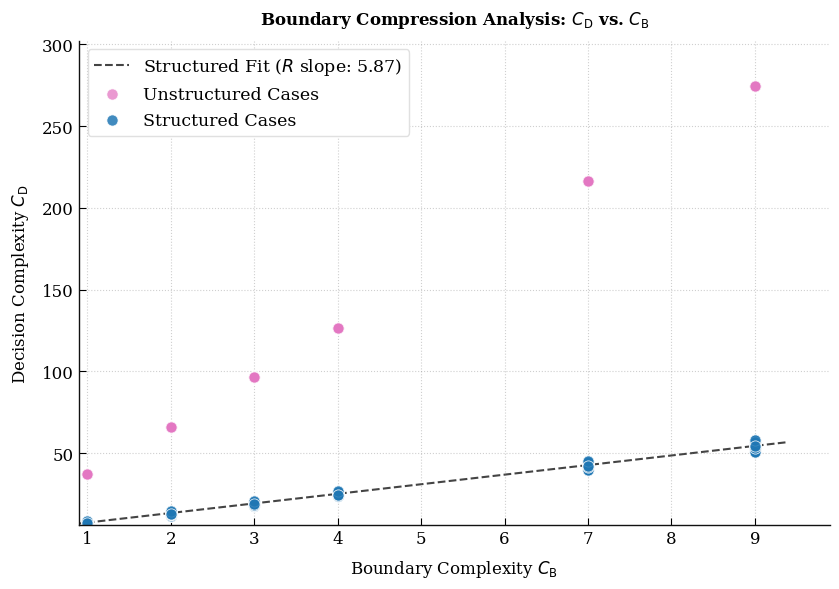

In [11]:
# Figure 10

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF2/data/fig10_boundary_compression_scatter_data_vF2.csv"
df = pd.read_csv(csv_path)

df_struct = df[df["structure"] == "structured"].copy()
df_unstruct = df[df["structure"] == "unstructured"].copy()

coef = np.polyfit(df_struct["C_B"], df_struct["C_D"], 1)
x_min, x_max = df_struct["C_B"].min(), df_struct["C_B"].max()
x_fit = np.linspace(x_min - (x_max - x_min)*0.05, x_max + (x_max - x_min)*0.05, 300)
y_fit = coef[0] * x_fit + coef[1]

fig, ax = plt.subplots(figsize=(8.5, 6))

color_struct = "#1F77B4"
color_unstruct = "#E377C2"

ax.plot(
    x_fit, y_fit,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    zorder=1,
    label=fr"Structured Fit ($R$ slope: {coef[0]:.2f})"
)

ax.scatter(
    df_unstruct["C_B"], df_unstruct["C_D"],
    s=65,
    color=color_unstruct,
    edgecolor="#ffffff",
    linewidths=0.6,
    alpha=0.75,
    zorder=2,
    label="Unstructured Cases"
)

ax.scatter(
    df_struct["C_B"], df_struct["C_D"],
    s=65,
    color=color_struct,
    edgecolor="#ffffff",
    linewidths=0.6,
    alpha=0.85,
    zorder=2,
    label="Structured Cases"
)

ax.set_xlabel(r"Boundary Complexity $C_{\mathrm{B}}$", fontsize=12, labelpad=8)
ax.set_ylabel(r"Decision Complexity $C_{\mathrm{D}}$", fontsize=12, labelpad=8)
ax.set_title(r"Boundary Compression Analysis: $C_{\mathrm{D}}$ vs. $C_{\mathrm{B}}$", fontsize=12, weight="bold", pad=12)

ax.set_xlim(df["C_B"].min() * 0.9, df["C_B"].max() * 1.1)
ax.set_ylim(df["C_D"].min() * 0.9, df["C_D"].max() * 1.1)

ax.grid(True, linestyle=":", alpha=0.35, color="#777777")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=12.5,
    loc="upper left"
)

sns.despine(ax=ax, top=True, right=True)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)


plt.tight_layout()
plt.show()


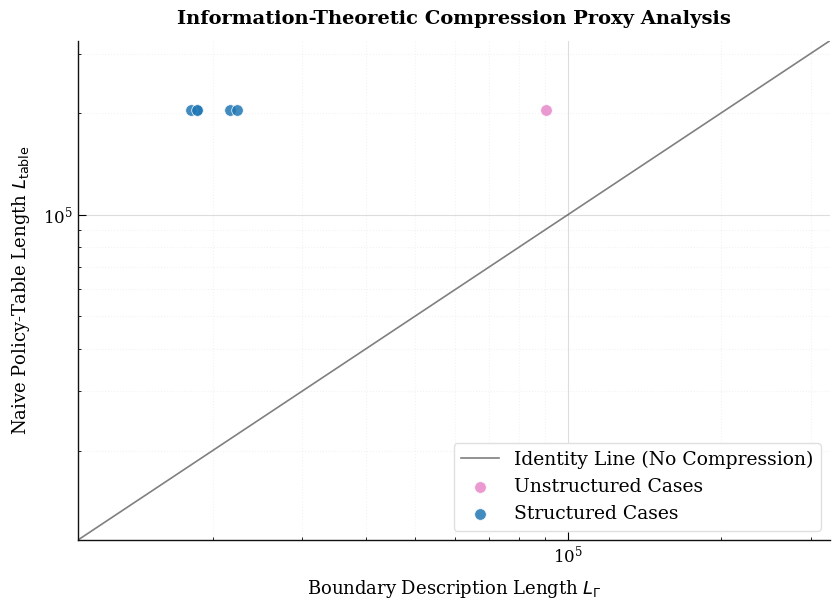

In [12]:
# Figure 11

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF2/data/fig11_mdl_compression_data_vF2.csv"
df = pd.read_csv(csv_path)

df_struct = df[df["structure"] == "structured"].copy()
df_unstruct = df[df["structure"] == "unstructured"].copy()

min_val = min(df["L_Gamma"].min(), df["L_table"].min()) * 0.6
max_val = max(df["L_Gamma"].max(), df["L_table"].max()) * 1.6
x_ref = np.geomspace(min_val, max_val, 300)

fig, ax = plt.subplots(figsize=(8.5, 6.2))

color_struct = "#1F77B4"
color_unstruct = "#E377C2"

ax.plot(
    x_ref, x_ref,
    color="#555555",
    linestyle="-",
    linewidth=1.2,
    alpha=0.75,
    zorder=1,
    label="Identity Line (No Compression)"
)

ax.scatter(
    df_unstruct["L_Gamma"], df_unstruct["L_table"],
    s=70,
    color=color_unstruct,
    edgecolor="#ffffff",
    linewidths=0.6,
    alpha=0.75,
    zorder=2,
    label="Unstructured Cases"
)

ax.scatter(
    df_struct["L_Gamma"], df_struct["L_table"],
    s=70,
    color=color_struct,
    edgecolor="#ffffff",
    linewidths=0.6,
    alpha=0.85,
    zorder=2,
    label="Structured Cases"
)

ax.set_xscale("log")
ax.set_yscale("log")

for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(mticker.LogFormatterMathtext())
    axis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

ax.set_xlabel(r"Boundary Description Length $L_{\Gamma}$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Naive Policy-Table Length $L_{\mathrm{table}}$", fontsize=13, labelpad=8)
ax.set_title("Information-Theoretic Compression Proxy Analysis", fontsize=14, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.20, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.10, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=13.5,
    loc="lower right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()


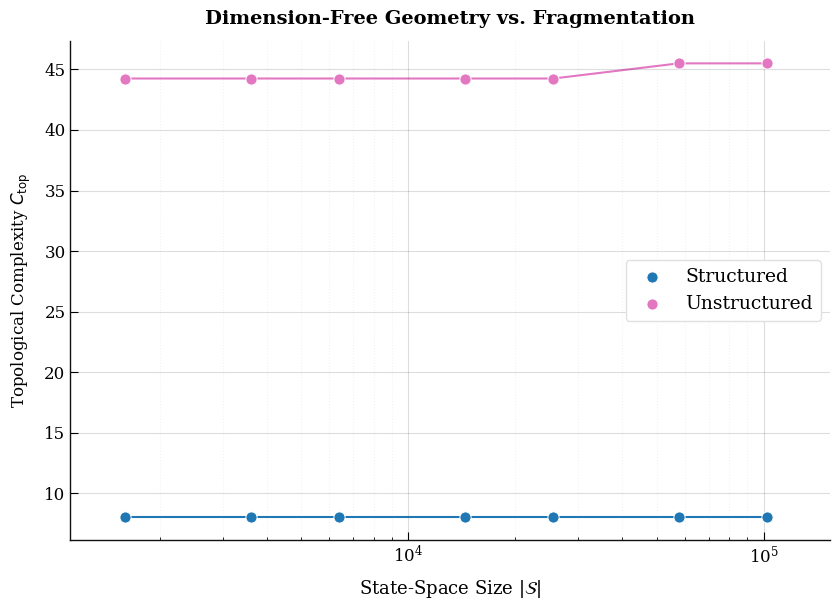

In [13]:
# Figure 12

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF2/data/fig12_dimension_free_geometry_data_vF2.csv"
df = pd.read_csv(csv_path)

df_struct = df[df["structure"] == "structured"].sort_values("states")
df_unstruct = df[df["structure"] == "unstructured"].sort_values("states")

fig, ax = plt.subplots(figsize=(8.5, 6.2))

color_struct = "#1F77B4"
color_unstruct = "#E377C2"

ax.plot(
    df_struct["states"], df_struct["C_top_mean"],
    color=color_struct, linestyle="-", linewidth=1.5, zorder=1
)
ax.plot(
    df_unstruct["states"], df_unstruct["C_top_mean"],
    color=color_unstruct, linestyle="-", linewidth=1.5, zorder=1
)

ax.errorbar(
    df_struct["states"], df_struct["C_top_mean"], yerr=df_struct["C_top_sd"],
    fmt="none", ecolor=color_struct, linewidth=1.2, capsize=0, alpha=0.6, zorder=2
)
ax.errorbar(
    df_unstruct["states"], df_unstruct["C_top_mean"], yerr=df_unstruct["C_top_sd"],
    fmt="none", ecolor=color_unstruct, linewidth=1.2, capsize=0, alpha=0.6, zorder=2
)

ax.scatter(
    df_struct["states"], df_struct["C_top_mean"],
    s=65, color=color_struct, edgecolor="#ffffff", linewidths=0.7, zorder=3,
    label="Structured"
)
ax.scatter(
    df_unstruct["states"], df_unstruct["C_top_mean"],
    s=65, color=color_unstruct, edgecolor="#ffffff", linewidths=0.7, zorder=3,
    label="Unstructured"
)


ax.set_xscale("log")

ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(df["states"].min() * 0.7, df["states"].max() * 1.5)

ax.set_xlabel(r"State-Space Size $|\mathcal{S}|$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Topological Complexity $C_{\mathrm{top}}$", fontsize=12, labelpad=8)
ax.set_title("Dimension-Free Geometry vs. Fragmentation", fontsize=14, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.20, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.10, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=13.5,
    loc="center right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()


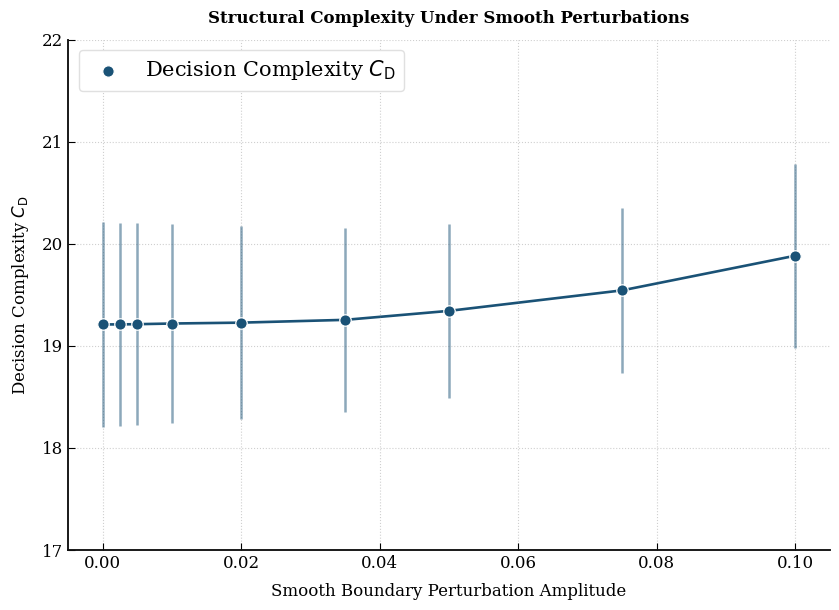

In [14]:
# Figure 13 A

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.35
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF2/data/fig13_robustness_to_smooth_boundary_noise_data_vF2.csv"
df = pd.read_csv(csv_path).sort_values("noise_amplitude")

fig, ax = plt.subplots(figsize=(8.5, 6.2))

main_color = "#1A5276"

ax.plot(
    df["noise_amplitude"], df["C_D_mean"],
    color=main_color,
    linestyle="-",
    linewidth=1.9,
    zorder=1
)

ax.errorbar(
    df["noise_amplitude"], df["C_D_mean"], yerr=df["C_D_sd"],
    fmt="none",
    ecolor=main_color,
    linewidth=1.8,
    capsize=0,
    alpha=0.5,
    zorder=2
)

ax.scatter(
    df["noise_amplitude"], df["C_D_mean"],
    s=68,
    color=main_color,
    edgecolor="#ffffff",
    linewidths=0.9,
    zorder=3,
    label=r"Decision Complexity $C_{\mathrm{D}}$"
)

ax.set_xlabel("Smooth Boundary Perturbation Amplitude", fontsize=12, labelpad=8)
ax.set_ylabel(r"Decision Complexity $C_{\mathrm{D}}$", fontsize=12, labelpad=8)
ax.set_title("Structural Complexity Under Smooth Perturbations", fontsize=12, weight="bold", pad=12)

x_min, x_max = df["noise_amplitude"].min(), df["noise_amplitude"].max()
ax.set_xlim(x_min - 0.05 * (x_max - x_min), x_max + 0.05 * (x_max - x_min))

ax.set_ylim(17.0, 22.0)

ax.grid(True, linestyle=":", alpha=0.35, color="#777777")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=15.,
    loc="upper left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()



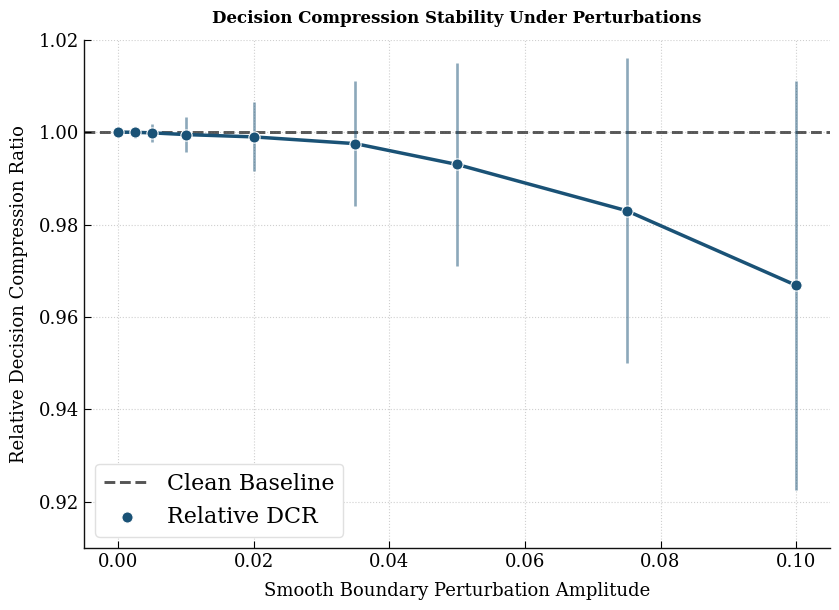

In [15]:
# Figure 13 B

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF2/data/fig13_robustness_to_smooth_boundary_noise_data_vF2.csv"
df = pd.read_csv(csv_path).sort_values("noise_amplitude")

fig, ax = plt.subplots(figsize=(8.5, 6.2))

main_color = "#1A5276"

ax.axhline(
    1.0,
    color="#555555",
    linestyle="--",
    linewidth=2.1,
    zorder=1,
    label="Clean Baseline"
)

ax.plot(
    df["noise_amplitude"], df["DCR_relative_to_clean_mean"],
    color=main_color,
    linestyle="-",
    linewidth=2.5,
    zorder=2
)

ax.errorbar(
    df["noise_amplitude"], df["DCR_relative_to_clean_mean"],
    yerr=df["DCR_relative_to_clean_sd"],
    fmt="none",
    ecolor=main_color,
    linewidth=1.9,
    capsize=0,
    alpha=0.5,
    zorder=3
)

ax.scatter(
    df["noise_amplitude"], df["DCR_relative_to_clean_mean"],
    s=65,
    color=main_color,
    edgecolor="#ffffff",
    linewidths=0.8,
    zorder=4,
    label="Relative DCR"
)

ax.set_xlabel("Smooth Boundary Perturbation Amplitude", fontsize=13, labelpad=8)
ax.set_ylabel("Relative Decision Compression Ratio", fontsize=13, labelpad=8)
ax.set_title("Decision Compression Stability Under Perturbations", fontsize=12, weight="bold", pad=12)

x_min, x_max = df["noise_amplitude"].min(), df["noise_amplitude"].max()
ax.set_xlim(x_min - 0.05 * (x_max - x_min), x_max + 0.05 * (x_max - x_min))

ax.set_ylim(0.91, 1.02)
ax.grid(True, linestyle=":", alpha=0.35, color="#777777")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=16.,
    loc="lower left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

plt.tight_layout()
plt.show()


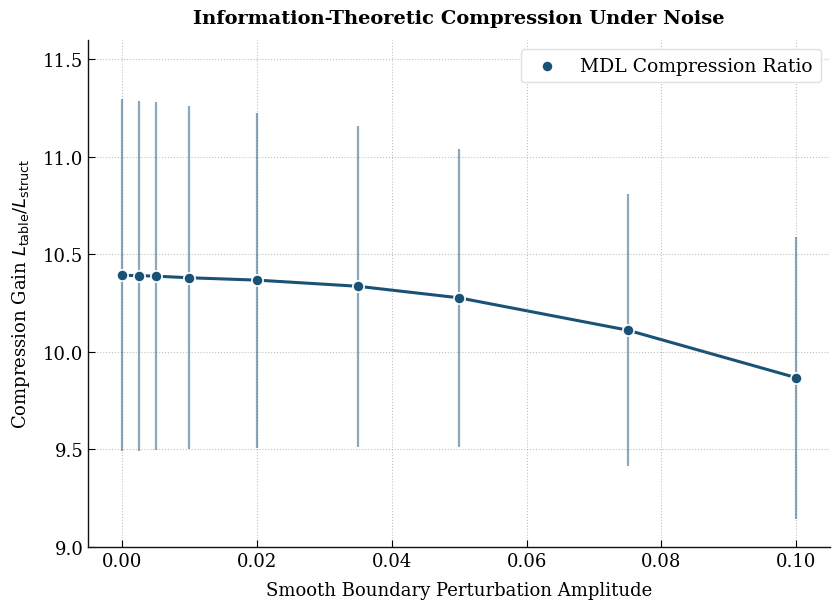

In [16]:
# Figure 13 C

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

csv_path = "C:/Users/fredy/Downloads/Results_section8_vF2/data/fig13_robustness_to_smooth_boundary_noise_data_vF2.csv"
df = pd.read_csv(csv_path).sort_values("noise_amplitude")

fig, ax = plt.subplots(figsize=(8.5, 6.2))

main_color = "#1A5276"

ax.plot(
    df["noise_amplitude"], df["table_to_struct_policy_ratio_mean"],
    color=main_color,
    linestyle="-",
    linewidth=2.2,
    zorder=1
)

ax.errorbar(
    df["noise_amplitude"], df["table_to_struct_policy_ratio_mean"],
    yerr=df["table_to_struct_policy_ratio_sd"],
    fmt="none",
    ecolor=main_color,
    linewidth=1.6,
    capsize=0,
    alpha=0.5,
    zorder=2
)

ax.scatter(
    df["noise_amplitude"], df["table_to_struct_policy_ratio_mean"],
    s=65,
    color=main_color,
    edgecolor="#ffffff",
    linewidths=1.2,
    zorder=3,
    label="MDL Compression Ratio"
)

ax.set_xlabel("Smooth Boundary Perturbation Amplitude", fontsize=13, labelpad=8)
ax.set_ylabel(r"Compression Gain $L_{\mathrm{table}} / L_{\mathrm{struct}}$", fontsize=13, labelpad=8)
ax.set_title("Information-Theoretic Compression Under Noise", fontsize=14, weight="bold", pad=12)

x_min, x_max = df["noise_amplitude"].min(), df["noise_amplitude"].max()
ax.set_xlim(x_min - 0.05 * (x_max - x_min), x_max + 0.05 * (x_max - x_min))

ax.set_ylim(9., 11.6)

ax.grid(True, linestyle=":", alpha=0.45, color="#777777")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=13.5,
    loc="upper right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


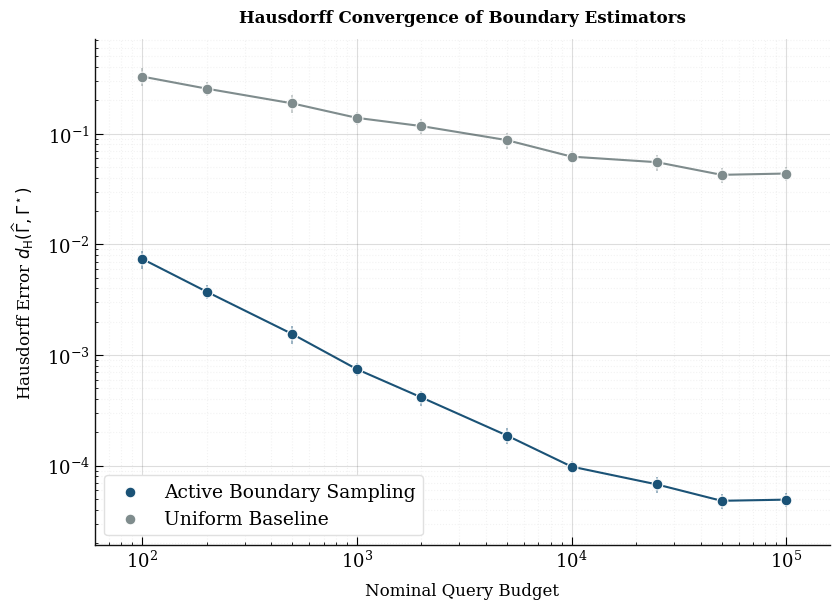

In [17]:
# =====================================================================
# Additional figures 2
# =====================================================================


# Figure 14

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

csv_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig14_hausdorff_convergence_data_robust_final.csv"
df = pd.read_csv(csv_path)

active = df[df["method"] == "active"].sort_values("budget")
uniform = df[df["method"] == "uniform"].sort_values("budget")

fig, ax = plt.subplots(figsize=(8.5, 6.2))

color_active = "#1A5276"
color_uniform = "#7F8C8D"

ax.plot(
    active["budget"], active["dH_mean"],
    color=color_active, linestyle="-", linewidth=1.5, zorder=1
)
ax.plot(
    uniform["budget"], uniform["dH_mean"],
    color=color_uniform, linestyle="-", linewidth=1.5, zorder=1
)

ax.errorbar(
    active["budget"], active["dH_mean"], yerr=active["dH_ci95"],
    fmt="none", ecolor=color_active, linewidth=1.2, capsize=0, alpha=0.5, zorder=2
)
ax.errorbar(
    uniform["budget"], uniform["dH_mean"], yerr=uniform["dH_ci95"],
    fmt="none", ecolor=color_uniform, linewidth=1.2, capsize=0, alpha=0.5, zorder=2
)

ax.scatter(
    active["budget"], active["dH_mean"],
    s=60, color=color_active, edgecolor="#ffffff", linewidths=0.8, zorder=3,
    label="Active Boundary Sampling"
)
ax.scatter(
    uniform["budget"], uniform["dH_mean"],
    s=60, color=color_uniform, edgecolor="#ffffff", linewidths=0.8, zorder=3,
    label="Uniform Baseline"
)

ax.set_xscale("log")
ax.set_yscale("log")

for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(mticker.LogFormatterMathtext())
    axis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(df["budget"].min() * 0.6, df["budget"].max() * 1.6)
ax.set_ylim(df["dH_mean"].min() * 0.4, df["dH_mean"].max() * 2.2)

ax.set_xlabel(r"Nominal Query Budget", fontsize=12, labelpad=8)
ax.set_ylabel(r"Hausdorff Error $d_{\mathrm{H}}(\widehat{\Gamma}, \Gamma^\star)$", fontsize=12, labelpad=8)
ax.set_title("Hausdorff Convergence of Boundary Estimators", fontsize=12, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.20, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.10, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=13.5,
    loc="lower left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


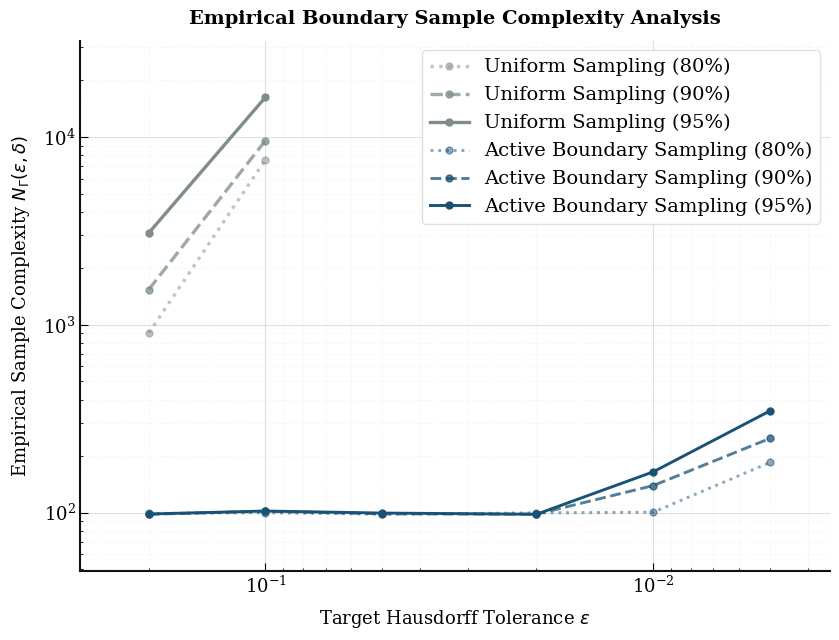

In [18]:
# Figure 15

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

csv_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig15_sample_complexity_data_robust_final2.csv"
df = pd.read_csv(csv_path)

fig, ax = plt.subplots(figsize=(8.5, 6.5))

color_active = "#1A5276"
color_uniform = "#7F8C8D"

styles = {
    0.80: ":",
    0.90: "--",
    0.95: "-"
}

alphas = {
    0.80: 0.50,
    0.90: 0.75,
    0.95: 1.00
}

confidences = [0.80, 0.90, 0.95]

for conf in confidences:
    tmp = df[(df["method"] == "uniform") & (df["confidence"] == conf)].sort_values("epsilon", ascending=False)

    ax.plot(
        tmp["epsilon"], tmp["N_Gamma"],
        marker="o", markersize=5, linewidth=2.4,
        linestyle=styles[conf], color=color_uniform, alpha=alphas[conf],
        zorder=2,
        label=f"Uniform Sampling ({int(conf * 100)}%)"
    )

for conf in confidences:
    tmp = df[(df["method"] == "active") & (df["confidence"] == conf)].sort_values("epsilon", ascending=False)

    ax.plot(
        tmp["epsilon"], tmp["N_Gamma"],
        marker="o", markersize=5, linewidth=2.1,
        linestyle=styles[conf], color=color_active, alpha=alphas[conf],
        zorder=3,
        label=f"Active Boundary Sampling ({int(conf * 100)}%)"
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.invert_xaxis()

for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(mticker.LogFormatterMathtext())
    axis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(df["epsilon"].max() * 1.5, df["epsilon"].min() * 0.7)
ax.set_ylim(df["N_Gamma"].min() * 0.5, df["N_Gamma"].max() * 2.0)

ax.set_xlabel(r"Target Hausdorff Tolerance $\epsilon$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Empirical Sample Complexity $N_{\Gamma}(\epsilon, \delta)$", fontsize=13, labelpad=8)
ax.set_title("Empirical Boundary Sample Complexity Analysis", fontsize=14, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.18, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.1, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=14,
    loc="best",
    ncol=1
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


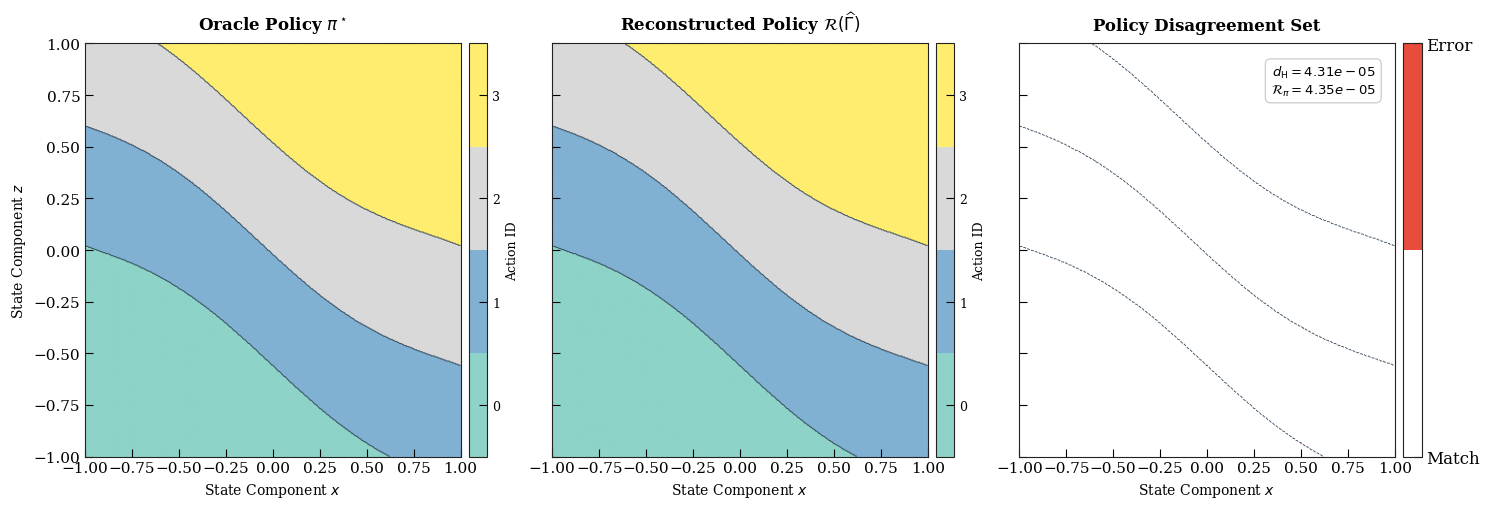

In [19]:
# Figure 16

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#222222"
plt.rcParams["axes.linewidth"] = 0.8

csv_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig16_policy_reconstruction_operator_grid_robust_final.csv"
df = pd.read_csv(csv_path)

x_vals = np.sort(df["x"].unique())
z_vals = np.sort(df["z"].unique())
X, Z = np.meshgrid(x_vals, z_vals)

PI_STAR = df.pivot(index="z", columns="x", values="pi_star").values
PI_HAT = df.pivot(index="z", columns="x", values="pi_hat").values
DISAGREE = df.pivot(index="z", columns="x", values="disagreement").values

d_H = 4.31e-5
R_pi = DISAGREE.mean()

num_actions = 4
cmap_policy = plt.get_cmap("Set3", num_actions)

cmap_disagree = mcolors.ListedColormap(["#ffffff", "#E74C3C"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True)
extent_rect = [x_vals.min(), x_vals.max(), z_vals.min(), z_vals.max()]

# ------------------------------------------------------------
# Panel 1 : Oracle Policy \pi^\star
# ------------------------------------------------------------
im0 = axes[0].imshow(
    PI_STAR, origin="lower", extent=extent_rect, aspect="auto",
    cmap=cmap_policy, vmin=-0.5, vmax=num_actions-0.5
)
axes[0].contour(X, Z, PI_STAR, levels=[0.5, 1.5, 2.5], colors="#2c3e50", linewidths=0.8, alpha=0.8)
axes[0].set_title(r"Oracle Policy $\pi^\star$", fontsize=12, weight="bold", pad=10)
axes[0].set_xlabel(r"State Component $x$", fontsize=10)
axes[0].set_ylabel(r"State Component $z$", fontsize=10)

divider0 = make_axes_locatable(axes[0])
cbar_ax0 = divider0.append_axes("right", size="5%", pad=0.08)
cbar0 = fig.colorbar(im0, cax=cbar_ax0, ticks=range(num_actions))
cbar0.set_label("Action ID", fontsize=9)
cbar0.ax.tick_params(labelsize=9)

# ------------------------------------------------------------
# Panel 2 : Reconstructed Policy R(\widehat{\Gamma})
# ------------------------------------------------------------
im1 = axes[1].imshow(
    PI_HAT, origin="lower", extent=extent_rect, aspect="auto",
    cmap=cmap_policy, vmin=-0.5, vmax=num_actions-0.5
)
axes[1].contour(X, Z, PI_HAT, levels=[0.5, 1.5, 2.5], colors="#2c3e50", linewidths=0.8, alpha=0.8)
axes[1].set_title(r"Reconstructed Policy $\mathcal{R}(\widehat{\Gamma})$", fontsize=12, weight="bold", pad=10)
axes[1].set_xlabel(r"State Component $x$", fontsize=10)

divider1 = make_axes_locatable(axes[1])
cbar_ax1 = divider1.append_axes("right", size="5%", pad=0.08)
cbar1 = fig.colorbar(im1, cax=cbar_ax1, ticks=range(num_actions))
cbar1.set_label("Action ID", fontsize=9)
cbar1.ax.tick_params(labelsize=9)

# ------------------------------------------------------------
# Panel 3 : Disagreement Set
# ------------------------------------------------------------
im2 = axes[2].imshow(
    DISAGREE, origin="lower", extent=extent_rect, aspect="auto",
    cmap=cmap_disagree, vmin=0, vmax=1
)
axes[2].contour(X, Z, PI_STAR, levels=[0.5, 1.5, 2.5], colors="#34495e", linewidths=0.6, linestyles="--")
axes[2].set_title("Policy Disagreement Set", fontsize=12, weight="bold", pad=10)
axes[2].set_xlabel(r"State Component $x$", fontsize=10)

axes[2].text(
    0.95, 0.95,
    rf"$d_{{\mathrm{{H}}}} = {d_H:.2e}$" + "\n" + rf"$\mathcal{{R}}_{{\pi}} = {R_pi:.2e}$",
    transform=axes[2].transAxes,
    va="top", ha="right", fontsize=9.5, fontfamily="monospace",
    bbox=dict(facecolor="#ffffff", edgecolor="#cccccc", boxstyle="round,pad=0.4", alpha=0.9)
)

divider2 = make_axes_locatable(axes[2])
cbar_ax2 = divider2.append_axes("right", size="5%", pad=0.08)
cbar2 = fig.colorbar(im2, cax=cbar_ax2, ticks=[0, 1])
cbar2.ax.set_yticklabels(["Match", "Error"], fontsize=12)


for ax in axes:
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.set_ylim(z_vals.min(), z_vals.max())
    ax.tick_params(axis="both", which="major", labelsize=11)

plt.tight_layout()
plt.show()


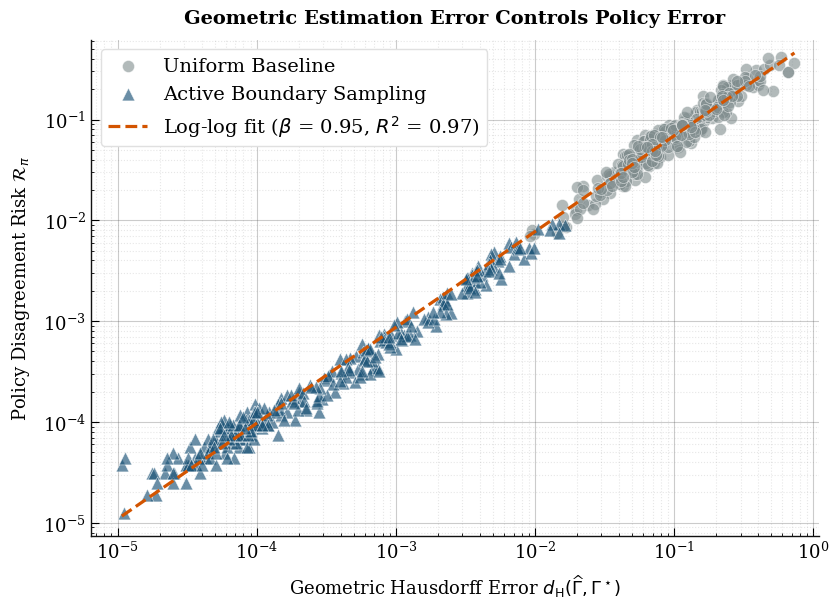

In [20]:

# Figure 17

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig17_policy_risk_vs_hausdorff_data_robust_final2.csv"
fit_path  = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig17_policy_risk_vs_hausdorff_fit_robust_final2.csv"

df = pd.read_csv(data_path)
fit = pd.read_csv(fit_path)

beta = float(fit["beta"].iloc[0])
intercept = float(fit["intercept"].iloc[0])
R2 = float(fit["R2"].iloc[0])

active = df[df["method"] == "active"].copy()
uniform = df[df["method"] == "uniform"].copy()

x_min, x_max = df["dH"].min(), df["dH"].max()
x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 300)
y_fit = np.exp(intercept) * x_fit**beta

fig, ax = plt.subplots(figsize=(8.5, 6.2))

color_active = "#1A5276"
color_uniform = "#7F8C8D"
color_fit = "#D35400"

ax.scatter(
    uniform["dH"], uniform["R_pi"],
    marker="o", s=75, color=color_uniform, edgecolor="#ffffff", linewidths=0.5,
    alpha=0.60, zorder=2, label="Uniform Baseline"
)

ax.scatter(
    active["dH"], active["R_pi"],
    marker="^", s=85, color=color_active, edgecolor="#ffffff", linewidths=0.5,
    alpha=0.65, zorder=3, label="Active Boundary Sampling"
)

ax.plot(
    x_fit, y_fit,
    color=color_fit, linestyle="--", linewidth=2.3, zorder=4,
    label=rf"Log-log fit ($\beta$ = {beta:.2f}, $R^2$ = {R2:.2f})"
)

ax.set_xscale("log")
ax.set_yscale("log")

for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(mticker.LogFormatterMathtext())
    axis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(x_min * 0.6, x_max * 1.5)
ax.set_ylim(df["R_pi"].min() * 0.6, df["R_pi"].max() * 1.5)

ax.set_xlabel(r"Geometric Hausdorff Error $d_{\mathrm{H}}(\widehat{\Gamma}, \Gamma^\star)$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$", fontsize=13, labelpad=8)
ax.set_title("Geometric Estimation Error Controls Policy Error", fontsize=14, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.3, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.2, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=14.,
    loc="upper left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()



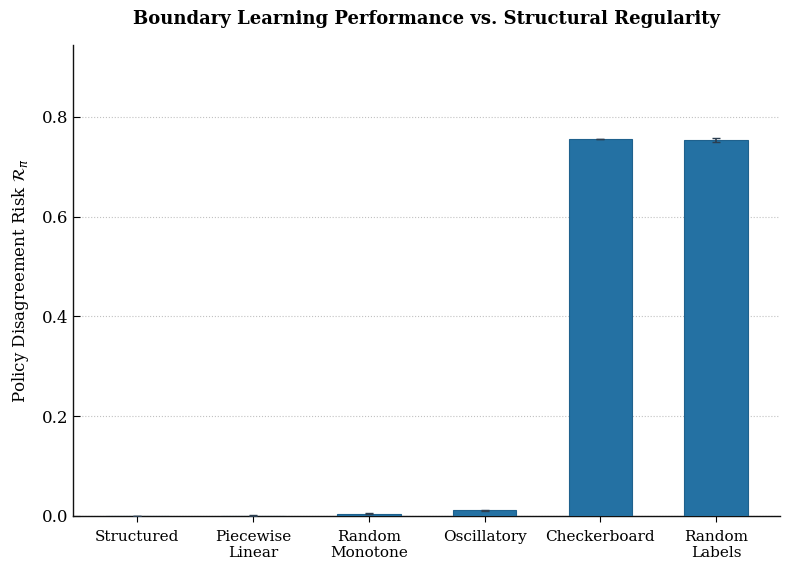

In [21]:
# Figure 18

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig18_learning_failure_modes_data_robust_final.csv"

df = pd.read_csv(data_path)

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "out"  # "
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4
plt.rcParams["ytick.major.size"] = 5

label_map = {
    "structured": "Structured",
    "piecewise_linear": "Piecewise\nLinear",
    "random_monotone": "Random\nMonotone",
    "oscillatory": "Oscillatory",
    "checkerboard": "Checkerboard",
    "random_labels": "Random\nLabels",
}
labels = [label_map[x] for x in df["family"]]

fig, ax = plt.subplots(figsize=(8.0, 5.8))

bar_color = "#2471A3"
edge_color = "#1F618D"
error_color = "#2C3E50"

bars = ax.bar(
    np.arange(len(df)),
    df["R_pi_mean"],
    yerr=df["R_pi_ci95"],
    width=0.55,
    color=bar_color,
    edgecolor=edge_color,
    linewidth=0.8,
    zorder=3,
    error_kw=dict(
        ecolor=error_color,
        linewidth=1.2,
        capsize=3,
        elinewidth=1.2
    )
)

ax.set_xticks(np.arange(len(df)))
ax.set_xticklabels(labels, fontsize=12.5, ha="center")

ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$", fontsize=12, labelpad=8)
ax.set_title("Boundary Learning Performance vs. Structural Regularity", fontsize=13, weight="bold", pad=15)

ax.set_ylim(0, df["R_pi_mean"].max() * 1.25)

ax.grid(True, axis="y", linestyle=":", alpha=0.45, color="#777777", zorder=1)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="y", which="major", labelsize=12)
ax.tick_params(axis="x", which="major", pad=6, labelsize=11)

plt.tight_layout()
plt.show()


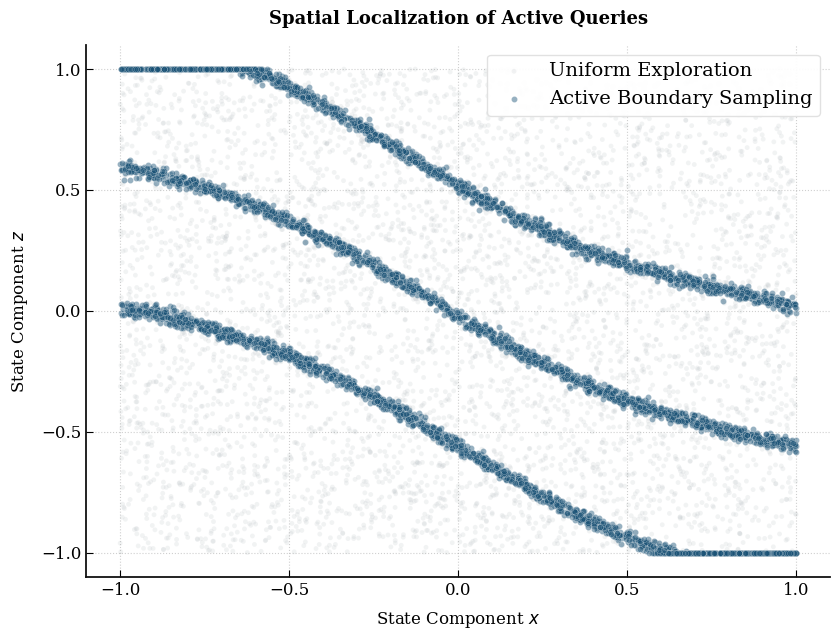

In [22]:
# Figure 19

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.3
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig19_active_query_localization_data_robust_final.csv"
df = pd.read_csv(data_path)

active = df[df["method"] == "active boundary sampling"]
uniform = df[df["method"] == "uniform"]

fig, ax = plt.subplots(figsize=(8.5, 6.5))

color_uniform = "#BDC3C7"
color_active = "#1A5276"

ax.scatter(
    uniform["x"], uniform["z"],
    s=12,
    color=color_uniform,
    alpha=0.20,
    edgecolors="none",
    zorder=1,
    label="Uniform Exploration"
)

ax.scatter(
    active["x"], active["z"],
    s=19,
    color=color_active,
    edgecolor="#ffffff",
    linewidths=0.3,
    alpha=0.45,
    zorder=2,
    label="Active Boundary Sampling"
)

ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))

ax.set_xlabel(r"State Component $x$", fontsize=12, labelpad=8)
ax.set_ylabel(r"State Component $z$", fontsize=12, labelpad=8)
ax.set_title("Spatial Localization of Active Queries", fontsize=13, weight="bold", pad=15)

ax.grid(True, linestyle=":", alpha=0.35, color="#777777", zorder=0)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=0.95,
    fontsize=14.,
    loc="upper right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=12)

plt.tight_layout()
plt.show()


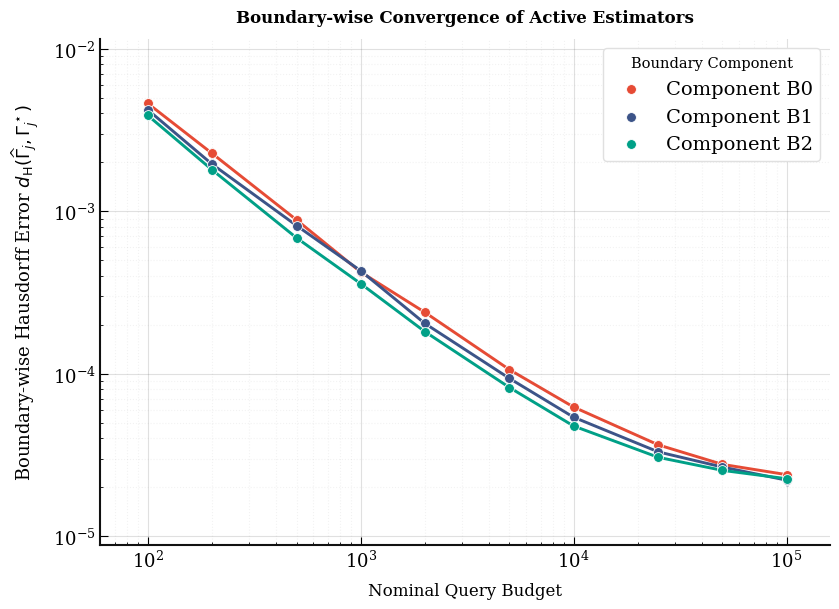

In [23]:
# Figure 20

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

csv_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig20_boundary_wise_convergence_data_robust_final.csv"
df = pd.read_csv(csv_path)

fig, ax = plt.subplots(figsize=(8.5, 6.2))

distinct_colors = ["#E64B35", "#3C5488", "#00A087"]  # Très distinctes

boundaries = sorted(df["boundary"].unique())
color_map = {b: distinct_colors[i] for i, b in enumerate(boundaries)}

for boundary in boundaries:
    sub = df[df["boundary"] == boundary].sort_values("budget")
    color = color_map[boundary]

    ax.plot(
        sub["budget"], sub["dH_j_mean"],
        color=color, linestyle="-", linewidth=2.1, zorder=1
    )

    ax.errorbar(
        sub["budget"], sub["dH_j_mean"], yerr=sub["dH_j_ci95"],
        fmt="none", ecolor=color, linewidth=1.9, capsize=0, alpha=0.5, zorder=2
    )

    ax.scatter(
        sub["budget"], sub["dH_j_mean"],
        s=50, color=color, edgecolor="#ffffff", linewidths=0.6, zorder=3,
        label=f"Component {boundary}"
    )

ax.set_xscale("log")
ax.set_yscale("log")

for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(mticker.LogFormatterMathtext())
    axis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(df["budget"].min() * 0.6, df["budget"].max() * 1.6)
ax.set_ylim(df["dH_j_mean"].min() * 0.4, df["dH_j_mean"].max() * 2.5)

ax.set_xlabel(r"Nominal Query Budget", fontsize=12, labelpad=8)
ax.set_ylabel(r"Boundary-wise Hausdorff Error $d_{\mathrm{H}}(\widehat{\Gamma}_j, \Gamma_j^\star)$", fontsize=13,labelpad=8)
ax.set_title("Boundary-wise Convergence of Active Estimators", fontsize=12, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.18, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.1, color="#888888")

ax.legend(
    title="Boundary Component",
    title_fontsize=10.5,
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=14,
    loc="upper right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


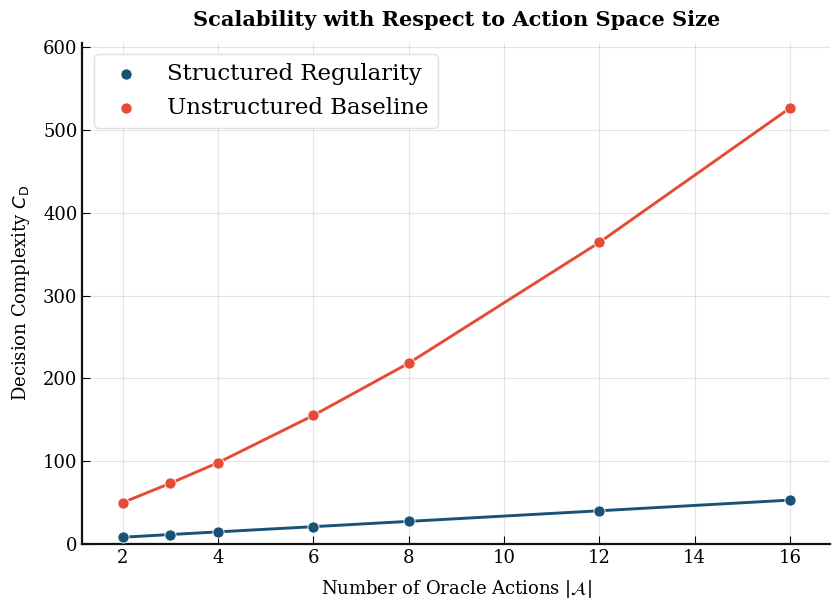

In [24]:
# Figure 21

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.6
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig21_action_scalability_data_robust_final.csv"
df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(8.5, 6.2))

color_structured = "#1A5276"
color_unstructured = "#E64B35"

ax.plot(
    df["actions"], df["C_D_structured_mean"],
    color=color_structured, linestyle="-", linewidth=2.1, zorder=1
)

ax.errorbar(
    df["actions"], df["C_D_structured_mean"], yerr=df["C_D_structured_ci95"],
    fmt="none", ecolor=color_structured, linewidth=1.6, capsize=0, alpha=0.4, zorder=2
)

ax.scatter(
    df["actions"], df["C_D_structured_mean"],
    s=65, color=color_structured, edgecolor="#ffffff", linewidths=0.6, zorder=3,
    label="Structured Regularity"
)

ax.plot(
    df["actions"], df["C_D_unstructured_mean"],
    color=color_unstructured, linestyle="-", linewidth=2.1, zorder=1
)

ax.errorbar(
    df["actions"], df["C_D_unstructured_mean"], yerr=df["C_D_unstructured_ci95"],
    fmt="none", ecolor=color_unstructured, linewidth=1.6, capsize=0, alpha=0.4, zorder=2
)

ax.scatter(
    df["actions"], df["C_D_unstructured_mean"],
    s=65, color=color_unstructured, edgecolor="#ffffff", linewidths=0.6, zorder=3,
    label="Unstructured Baseline"
)

x_min, x_max = df["actions"].min(), df["actions"].max()
ax.set_xlim(x_min - (x_max - x_min) * 0.06, x_max + (x_max - x_min) * 0.06)
ax.set_ylim(0, max(df["C_D_unstructured_mean"].max(), df["C_D_structured_mean"].max()) * 1.15)

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.set_xlabel(r"Number of Oracle Actions $|\mathcal{A}|$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Decision Complexity $C_{\mathrm{D}}$", fontsize=13, labelpad=8)
ax.set_title("Scalability with Respect to Action Space Size", fontsize=15, weight="bold", pad=12)

ax.grid(True, linestyle="-", alpha=0.15, color="#555555")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=16.5,
    loc="upper left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


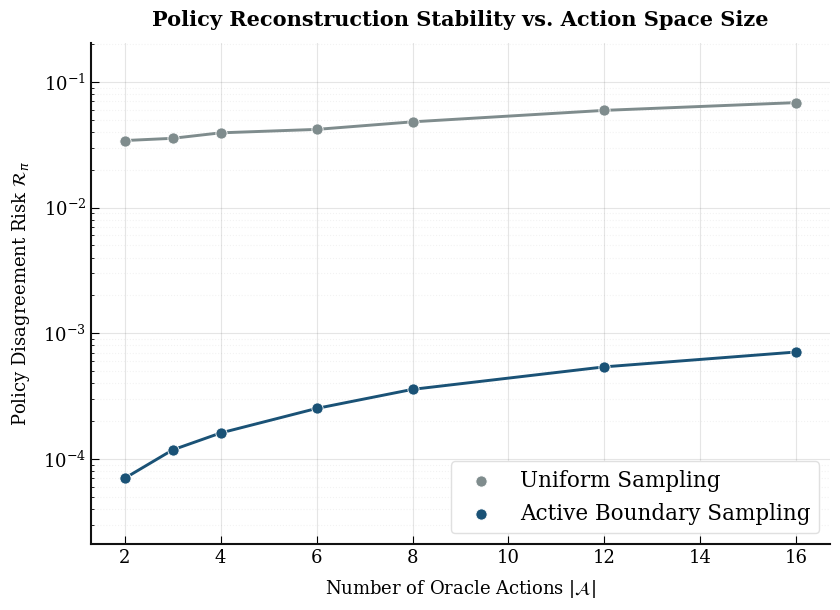

In [25]:
# Figure 22

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig21_action_scalability_raw_robust_final.csv"

df = pd.read_csv(data_path)

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 6
plt.rcParams["ytick.major.size"] = 6

stats = (
    df.groupby("actions")
      .agg(
          R_pi_active_mean=("R_pi_active", "mean"),
          R_pi_active_ci95=("R_pi_active", lambda x: 1.96 * x.std(ddof=1) / (len(x)**0.5)),
          R_pi_uniform_mean=("R_pi_uniform", "mean"),
          R_pi_uniform_ci95=("R_pi_uniform", lambda x: 1.96 * x.std(ddof=1) / (len(x)**0.5)),
      )
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8.5, 6.2))


color_active = "#1A5276"
color_uniform = "#7F8C8D"

ax.plot(
    stats["actions"], stats["R_pi_uniform_mean"],
    color=color_uniform, linestyle="-", linewidth=2.1, zorder=2
)
ax.errorbar(
    stats["actions"], stats["R_pi_uniform_mean"], yerr=stats["R_pi_uniform_ci95"],
    fmt="none", ecolor=color_uniform, linewidth=1.9, capsize=0, alpha=0.4, zorder=2
)
ax.scatter(
    stats["actions"], stats["R_pi_uniform_mean"],
    s=65, color=color_uniform, edgecolor="#ffffff", linewidths=0.6, zorder=3,
    label="Uniform Sampling"
)

ax.plot(
    stats["actions"], stats["R_pi_active_mean"],
    color=color_active, linestyle="-", linewidth=2.1, zorder=4
)
ax.errorbar(
    stats["actions"], stats["R_pi_active_mean"], yerr=stats["R_pi_active_ci95"],
    fmt="none", ecolor=color_active, linewidth=1.9, capsize=0, alpha=0.4, zorder=4
)
ax.scatter(
    stats["actions"], stats["R_pi_active_mean"],
    s=65, color=color_active, edgecolor="#ffffff", linewidths=0.6, zorder=5,
    label="Active Boundary Sampling"
)

ax.set_yscale("log")

ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
x_min, x_max = stats["actions"].min(), stats["actions"].max()
ax.set_xlim(x_min - (x_max - x_min) * 0.05, x_max + (x_max - x_min) * 0.05)

ax.set_ylim(stats["R_pi_active_mean"].min() * 0.3, stats["R_pi_uniform_mean"].max() * 3.0)

ax.set_xlabel(r"Number of Oracle Actions $|\mathcal{A}|$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$", fontsize=13, labelpad=8)
ax.set_title("Policy Reconstruction Stability vs. Action Space Size", fontsize=15, weight="bold", pad=12)

ax.grid(True, which="major", linestyle="-", alpha=0.15, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.1, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=15.5,
    loc="lower right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


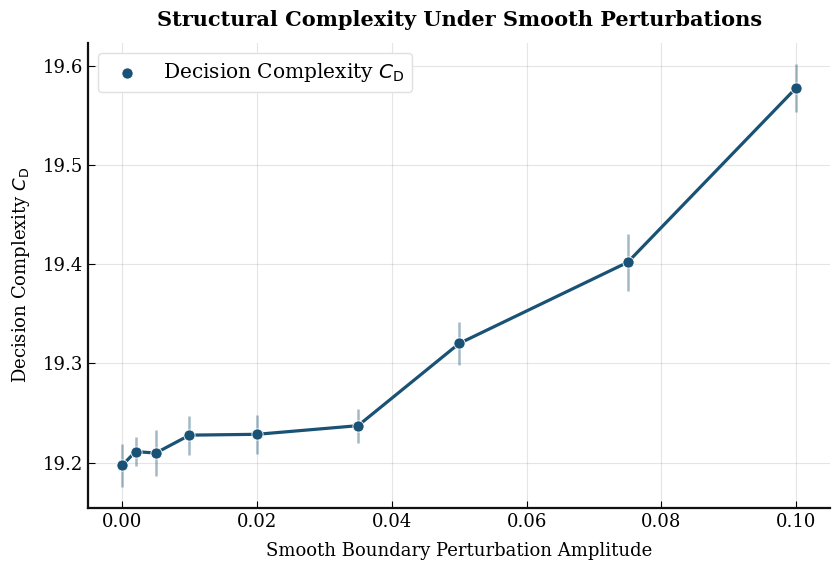

In [26]:
# Figure 23

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.6
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig23_perturbation_robustness_data_robust_final3.csv"
df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(8.5, 5.8))

color_robust = "#1A5276"

ax.plot(
    df["amplitude"], df["C_D_mean"],
    color=color_robust, linestyle="-", linewidth=2.3, zorder=1
)

ax.errorbar(
    df["amplitude"], df["C_D_mean"], yerr=df["C_D_ci95"],
    fmt="none", ecolor=color_robust, linewidth=1.8, capsize=0, alpha=0.4, zorder=2
)

ax.scatter(
    df["amplitude"], df["C_D_mean"],
    s=65, color=color_robust, edgecolor="#ffffff", linewidths=0.6, zorder=3,
    label=r"Decision Complexity $C_{\mathrm{D}}$"
)

x_min, x_max = df["amplitude"].min(), df["amplitude"].max()
ax.set_xlim(x_min - (x_max - x_min) * 0.05, x_max + (x_max - x_min) * 0.05)

ax.set_xlabel(r"Smooth Boundary Perturbation Amplitude", fontsize=13, labelpad=8)
ax.set_ylabel(r"Decision Complexity $C_{\mathrm{D}}$", fontsize=13, labelpad=8)
ax.set_title("Structural Complexity Under Smooth Perturbations", fontsize=15, weight="bold", pad=12)

ax.grid(True, linestyle="-", alpha=0.15, color="#555555")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=14.5,
    loc="upper left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()



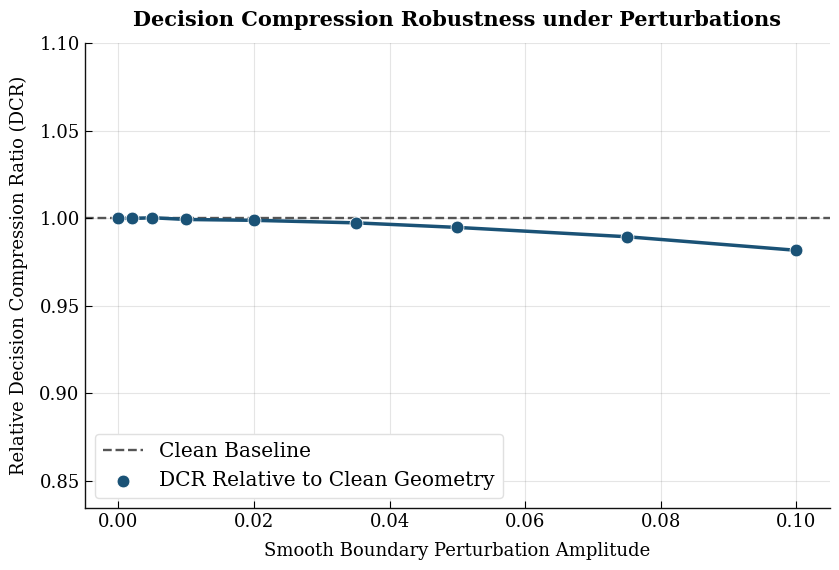

In [27]:
# Figure 24

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig23_perturbation_robustness_data_robust_final3.csv"
df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(8.5, 5.8))

color_dcr = "#1A5276"
color_baseline = "#555555"

ax.axhline(
    1.0,
    color=color_baseline, linestyle="--", linewidth=1.7, zorder=1,
    label="Clean Baseline"
)

ax.plot(
    df["amplitude"], df["relative_DCR_mean"],
    color=color_dcr, linestyle="-", linewidth=2.5, zorder=2
)

ax.errorbar(
    df["amplitude"], df["relative_DCR_mean"], yerr=df["relative_DCR_ci95"],
    fmt="none", ecolor=color_dcr, linewidth=2.1, capsize=0, alpha=0.4, zorder=3
)

ax.scatter(
    df["amplitude"], df["relative_DCR_mean"],
    s=85, color=color_dcr, edgecolor="#ffffff", linewidths=0.6, zorder=4,
    label="DCR Relative to Clean Geometry"
)

x_min, x_max = df["amplitude"].min(), df["amplitude"].max()
ax.set_xlim(x_min - (x_max - x_min) * 0.05, x_max + (x_max - x_min) * 0.05)

ax.set_ylim(df["relative_DCR_mean"].min() * 0.85, max(1.0, df["relative_DCR_mean"].max()) * 1.1)

ax.set_xlabel(r"Smooth Boundary Perturbation Amplitude", fontsize=13, labelpad=8)
ax.set_ylabel(r"Relative Decision Compression Ratio (DCR)", fontsize=13, labelpad=8)
ax.set_title("Decision Compression Robustness under Perturbations", fontsize=15, weight="bold", pad=12)

ax.grid(True, linestyle="-", alpha=0.15, color="#555555")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=14.5,
    loc="lower left"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()



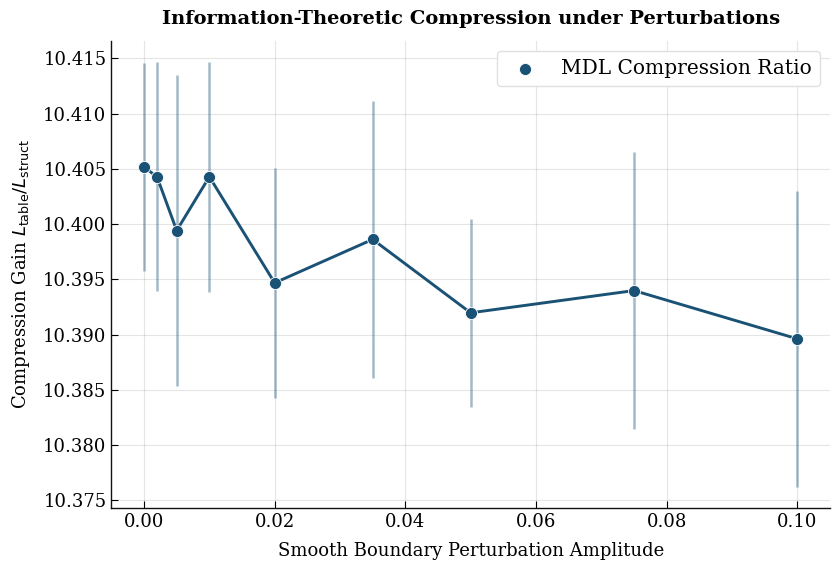

In [28]:
# Figure 25

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig23_perturbation_robustness_data_robust_final3.csv"
df = pd.read_csv(data_path)

fig, ax = plt.subplots(figsize=(8.5, 5.8))

color_mdl = "#1A5276"

ax.plot(
    df["amplitude"], df["MDL_gain_mean"],
    color=color_mdl, linestyle="-", linewidth=2.1, zorder=1
)

ax.errorbar(
    df["amplitude"], df["MDL_gain_mean"], yerr=df["MDL_gain_ci95"],
    fmt="none", ecolor=color_mdl, linewidth=1.8, capsize=0, alpha=0.4, zorder=2
)

ax.scatter(
    df["amplitude"], df["MDL_gain_mean"],
    s=75, color=color_mdl, edgecolor="#ffffff", linewidths=0.6, zorder=3,
    label="MDL Compression Ratio"
)

x_min, x_max = df["amplitude"].min(), df["amplitude"].max()
ax.set_xlim(x_min - (x_max - x_min) * 0.05, x_max + (x_max - x_min) * 0.05)

ax.set_xlabel(r"Smooth Boundary Perturbation Amplitude", fontsize=13, labelpad=8)
ax.set_ylabel(r"Compression Gain $L_{\mathrm{table}} / L_{\mathrm{struct}}$", fontsize=13, labelpad=8)
ax.set_title("Information-Theoretic Compression under Perturbations", fontsize=14, weight="bold", pad=12)

ax.grid(True, linestyle="-", alpha=0.15, color="#555555")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=14.5,
    loc="upper right"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()



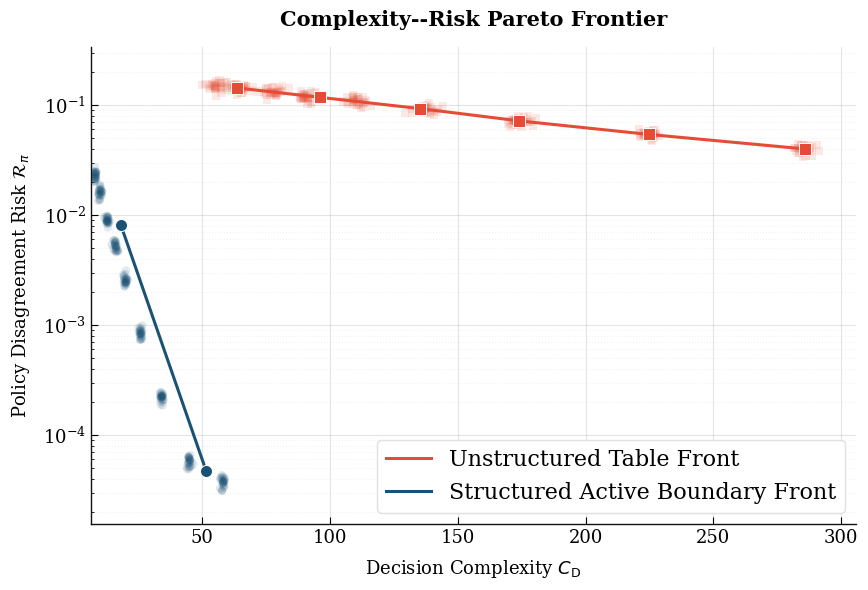

In [29]:
# Figure 26

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig26_pareto_complexity_risk_points_robust_final.csv"
df = pd.read_csv(data_path)

structured = df[df["method"] == "structured active boundary"]
unstructured = df[df["method"] == "unstructured table"]

structured_front = structured.groupby("C_bin", observed=True)[["C_D", "R_pi"]].mean().sort_values("C_D")
unstructured_front = unstructured.groupby("C_bin", observed=True)[["C_D", "R_pi"]].mean().sort_values("C_D")

fig, ax = plt.subplots(figsize=(8.8, 6.0))

color_struct = "#1A5276"
color_unstruct = "#E64B35"

ax.scatter(
    unstructured["C_D"], unstructured["R_pi"],
    s=35, color=color_unstruct, marker="s", alpha=0.12, edgecolors="none", zorder=1
)

ax.scatter(
    structured["C_D"], structured["R_pi"],
    s=35, color=color_struct, marker="o", alpha=0.12, edgecolors="none", zorder=2
)

ax.plot(
    unstructured_front["C_D"], unstructured_front["R_pi"],
    color=color_unstruct, linestyle="-", linewidth=2.2, zorder=3,
    label="Unstructured Table Front"
)
ax.scatter(
    unstructured_front["C_D"], unstructured_front["R_pi"],
    s=65, color=color_unstruct, marker="s", edgecolor="#ffffff", linewidths=0.7, zorder=5
)

ax.plot(
    structured_front["C_D"], structured_front["R_pi"],
    color=color_struct, linestyle="-", linewidth=2.2, zorder=4,
    label="Structured Active Boundary Front"
)
ax.scatter(
    structured_front["C_D"], structured_front["R_pi"],
    s=75, color=color_struct, marker="o", edgecolor="#ffffff", linewidths=0.7, zorder=6
)

ax.set_yscale("log")

ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(df["C_D"].min() * 0.9, df["C_D"].max() * 1.05)
ax.set_ylim(df["R_pi"].min() * 0.5, df["R_pi"].max() * 2.0)

ax.set_xlabel(r"Decision Complexity $C_{\mathrm{D}}$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$", fontsize=13, labelpad=8)
ax.set_title("Complexity--Risk Pareto Frontier", fontsize=15, weight="bold", pad=15)

ax.grid(True, which="major", linestyle="-", alpha=0.15, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.1, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=16.,
    loc="best"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()


C:\Users\fredy\AppData\Local\Temp\ipykernel_17184\3470754775.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


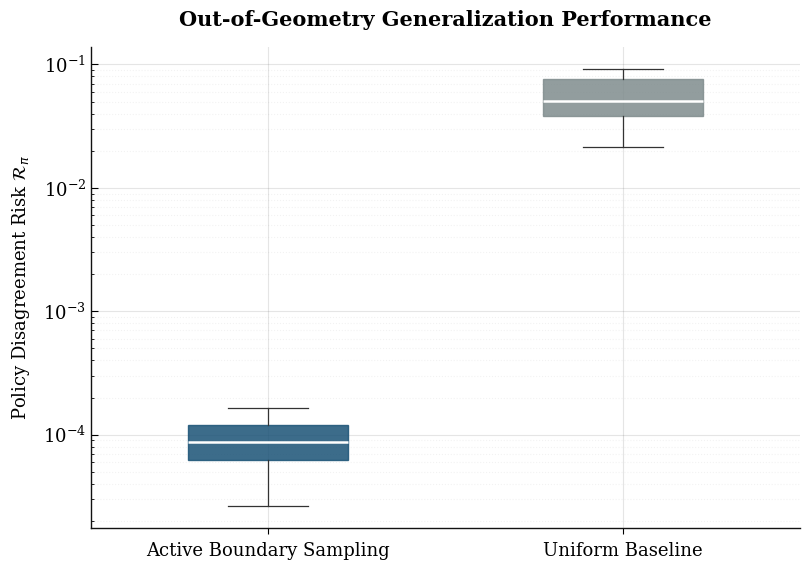

In [30]:
# Figure 27

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig27_multigeometry_generalization_data_robust_final3.csv"
df = pd.read_csv(data_path)

active = df[df["method"] == "active"]["R_pi_mean"]
uniform = df[df["method"] == "uniform"]["R_pi_mean"]

fig, ax = plt.subplots(figsize=(8.2, 5.8))

color_active = "#1A5276"
color_uniform = "#7F8C8D"

box_data = [active, uniform]
labels = ["Active Boundary Sampling", "Uniform Baseline"]

box = ax.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,
    widths=0.45,
    zorder=3,
    showmeans=False,
    flierprops=dict(
        marker="o",
        markersize=3.5,
        markerfacecolor="none",
        markeredgecolor="#888888",
        markeredgewidth=0.5,
        alpha=0.4
    ),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(color="#333333", linewidth=0.9, linestyle="-"),
    capprops=dict(color="#333333", linewidth=0.9),
    medianprops=dict(color="#FFFFFF", linewidth=1.8)
)

colors = [color_active, color_uniform]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.85)

ax.set_yscale("log")

ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$", fontsize=13, labelpad=8)
ax.set_title("Out-of-Geometry Generalization Performance", fontsize=15, weight="bold", pad=15)

ax.grid(True, which="major", linestyle="-", alpha=0.15, color="#555555", zorder=1)
ax.grid(True, which="minor", linestyle=":", alpha=0.1, color="#888888", zorder=1)

sns.despine(ax=ax, top=True, right=True)

ax.tick_params(axis="x", which="major", labelsize=13, pad=6)
ax.tick_params(axis="y", which="major", labelsize=13)

plt.tight_layout()
plt.show()


C:\Users\fredy\AppData\Local\Temp\ipykernel_17184\266446647.py:70: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(df["R_pi"].min() * 0.4, df["R_pi"].max() * 2.5)


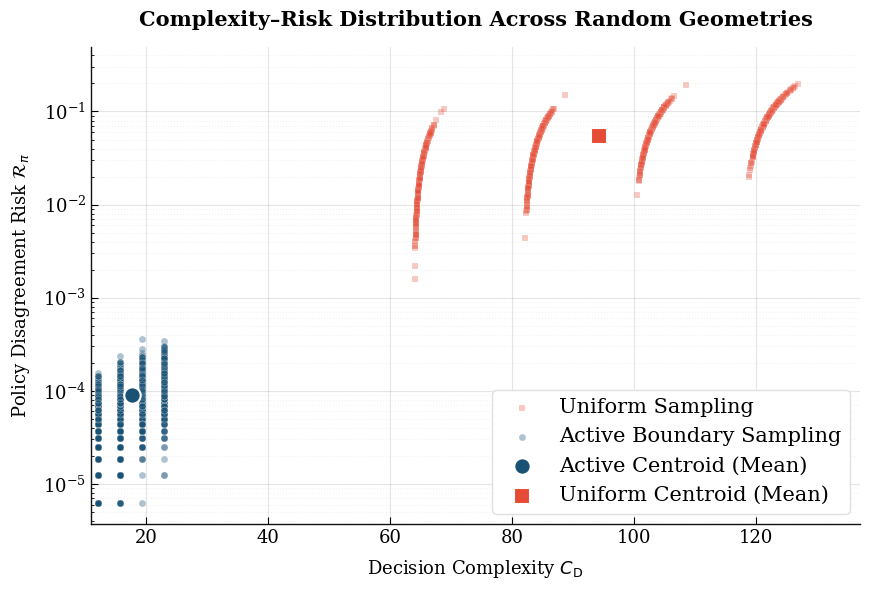

In [31]:
# Figure 28

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.edgecolor"] = "#111111"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5

data_path = "C:/Users/fredy/Downloads/Results_section8_learning_robust_final3/data/fig27_multigeometry_generalization_raw_robust_final3.csv"
df = pd.read_csv(data_path)

active = df[df["method"] == "active"]
uniform = df[df["method"] == "uniform"]

fig, ax = plt.subplots(figsize=(8.8, 6.0),)

color_active = "#1A5276"
color_uniform = "#E64B35"

ax.scatter(
    uniform["C_D"], uniform["R_pi"],
    s=25,
    color=color_uniform,
    marker="s",
    alpha=0.30,
    edgecolors="#ffffff",
    linewidths=0.3,
    zorder=2,
    label="Uniform Sampling"
)

ax.scatter(
    active["C_D"], active["R_pi"],
    s=25,
    color=color_active,
    marker="o",
    alpha=0.35,
    edgecolors="#ffffff",
    linewidths=0.3,
    zorder=3,
    label="Active Boundary Sampling"
)

mean_c_active = active["C_D"].mean()
mean_r_active = active["R_pi"].mean()
ax.scatter(
    mean_c_active, mean_r_active,
    s=140, color=color_active, marker="o",
    edgecolors="#ffffff", linewidths=1.5, zorder=5,
    label="Active Centroid (Mean)"
)

mean_c_uniform = uniform["C_D"].mean()
mean_r_uniform = uniform["R_pi"].mean()
ax.scatter(
    mean_c_uniform, mean_r_uniform,
    s=140, color=color_uniform, marker="s",
    edgecolors="#ffffff", linewidths=1.5, zorder=4,
    label="Uniform Centroid (Mean)"
)

ax.set_yscale("log")

ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlim(df["C_D"].min() * 0.9, df["C_D"].max() * 1.08)
ax.set_ylim(df["R_pi"].min() * 0.4, df["R_pi"].max() * 2.5)

ax.set_xlabel(r"Decision Complexity $C_{\mathrm{D}}$", fontsize=13, labelpad=8)
ax.set_ylabel(r"Policy Disagreement Risk $\mathcal{R}_{\pi}$", fontsize=13, labelpad=8)
ax.set_title("Complexity–Risk Distribution Across Random Geometries", fontsize=15, weight="bold", pad=15)

ax.grid(True, which="major", linestyle="-", alpha=0.15, color="#555555")
ax.grid(True, which="minor", linestyle=":", alpha=0.1, color="#888888")

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#e0e0e0",
    framealpha=1.0,
    fontsize=15.0,
    loc="best"
)

sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.show()